# Preprocessing

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import TensorDataset, DataLoader, random_split
import torch.nn.functional as F
from sklearn.metrics import f1_score
from thop import profile
from torchinfo import summary
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
def remove_punctuation(text : str) -> str:
    text = text.replace('.', ' ').replace('-', ' ').replace('/', ' ').replace(':', ' ').replace("[", "").replace("]", "").replace("'", "").replace('"', '').replace(',', ' ').replace('(', ' ').replace(')', ' ')
    all_text = text.split(' ')
    return all_text

def text_list_to_int(text_to_convert : list) -> list:
    output = []
    for i in range(len(text_to_convert)):
        if text_to_convert[i] == 'AM':
            output.append(1)
        elif text_to_convert[i] == 'PM':
            output.append(2)
        else:
            output.append(int(text_to_convert[i] if text_to_convert[i] != '' else 0))
    return output

def sum_array(arr : list) -> int:
    sum = 0
    for i in range(len(arr)):
        sum += arr[i]
    return sum

def numerize_labels(labels : list) -> list:
    output = []
    for i in range(len(labels)):
        if labels[i].lower() == 'benign':
            output.append(0)
        else:
            output.append(1)
    return output

Sample Usage of Helper Functions

In [3]:
row_one = pd.read_csv('final_dataset.csv', nrows=1)
row_one = row_one.values.tolist()[0]

row_one, label = row_one[:-1], row_one[-1]

for i in range(len(row_one)):
    row_one[i] = remove_punctuation(str(row_one[i]))
for i in range(len(row_one)):
    row_one[i] = text_list_to_int(row_one[i])
for i in range(len(row_one)):
    row_one[i] = sum_array(row_one[i])

print(row_one, label, numerize_labels([label]))
print(len(row_one))

[624, 5447, 482, 4504, 375, 80, 6, 2103, 3974862, 29, 44, 86, 59811, 86, 0, 9655172413793098, 969799083226479, 1460, 0, 3409090910445, 271897529280, 950821452392, 365417466065505, 41666721872, 31665559141, 1566821, 167, 3735347, 133430, 6887465068, 1805015, 167, 3974862, 65116371510, 8205991249, 1566821, 3997, 0, 0, 0, 0, 768, 896, 295850774190406, 69566691875100, 0, 1460, 4189189189995, 8624277196534, 439072521, 0, 1, 0, 0, 0, 0, 0, 0, 1, 5068493151505, 9655172413793107, 340909092268, 0, 0, 0, 0, 0, 0, 29, 86, 44, 59811, 1, 5840, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0] ddos [1]
84


# Model Creation

In [4]:
class DeepNeuralNet(nn.Module):
    def __init__(self, layer_1_units=32, layer_2_units=2, dropout_rate=0.2):
        super(DeepNeuralNet, self).__init__()

        self.fc1 = nn.Linear(84, layer_1_units)  # input from rows -> 84 features
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(dropout_rate)
        self.hid_1 = nn.Linear(layer_1_units, 128)
        self.hid_2 = nn.Linear(128, 64)
        self.dropout_2 = nn.Dropout(dropout_rate)
        self.hid_3 = nn.Linear(64, 32)
        self.dropout_3 = nn.Dropout(dropout_rate)
        #self.batch_1 = nn.BatchNorm2d(24)
        self.fc2 = nn.Linear(32, layer_2_units)  # Output layer (2 classes)

    def forward(self, x):
        x = x.view(x.size(0), -1)  # Flatten input
        x = self.relu(self.fc1(x))
        x = self.dropout(x)
        x = torch.relu(self.hid_1(x))
        x = torch.relu(self.hid_2(x))
        x = self.dropout_2(x)
        x = torch.relu(self.hid_3(x))
        x = self.dropout_3(x)
        #x = self.batch_1(x)
        x = self.fc2(x)  # No softmax here (handled in loss function)
        return x

In [5]:
def create_model(layer_1_units=32, layer_2_units=10, learning_rate=0.001, dropout_rate=0.2):
    model = DeepNeuralNet(layer_1_units, layer_2_units, dropout_rate)

    # Define loss function and optimizer
    criterion = nn.CrossEntropyLoss()  # Softmax is included in CrossEntropyLoss
    #optimizer = optim.SGD(model.parameters(), lr=learning_rate)
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)

    return model, criterion, optimizer


In [6]:
model, criterion, optimizer = create_model()

# Print model summary
print(model)

DeepNeuralNet(
  (fc1): Linear(in_features=84, out_features=32, bias=True)
  (relu): ReLU()
  (dropout): Dropout(p=0.2, inplace=False)
  (hid_1): Linear(in_features=32, out_features=128, bias=True)
  (hid_2): Linear(in_features=128, out_features=64, bias=True)
  (dropout_2): Dropout(p=0.2, inplace=False)
  (hid_3): Linear(in_features=64, out_features=32, bias=True)
  (dropout_3): Dropout(p=0.2, inplace=False)
  (fc2): Linear(in_features=32, out_features=10, bias=True)
)


## Functions for Training and Testing the Model

In [7]:
def train_model(model, train_loader, test_loader, criterion, optimizer, num_epochs=5, device="cpu"):
    model.to(device)  # Move model to the specified device (CPU/GPU)

    # Lists to store the loss and accuracy values
    train_losses = []
    train_accuracies = []
    val_losses = []
    val_accuracies = []

    for epoch in range(num_epochs):
        model.train()  # Set model to training mode
        running_loss = 0.0
        correct = 0
        total = 0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)  # Move data to device

            optimizer.zero_grad()  # Reset gradients
            outputs = model(images)  # Forward pass
            loss = criterion(outputs, labels)  # Compute loss
            loss.backward()  # Backpropagation
            optimizer.step()  # Update weights

            running_loss += loss.item()
            _, predicted = outputs.max(1)  # Get class with highest probability
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

        # Training metrics for the epoch
        epoch_loss = running_loss / len(train_loader)
        epoch_acc = 100 * correct / total
        train_losses.append(epoch_loss)
        train_accuracies.append(epoch_acc)

        # Validation phase
        model.eval()  # Set model to evaluation mode
        val_loss = 0.0
        val_correct = 0
        val_total = 0
        with torch.no_grad():  # No gradients needed for validation
            for images, labels in test_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)
                val_loss += loss.item()
                _, predicted = outputs.max(1)
                val_total += labels.size(0)
                val_correct += (predicted == labels).sum().item()

        # Validation metrics for the epoch
        val_epoch_loss = val_loss / len(test_loader)
        val_epoch_acc = 100 * val_correct / val_total
        val_losses.append(val_epoch_loss)
        val_accuracies.append(val_epoch_acc)

        # Print epoch metrics
        print(f"Epoch {epoch+1}/{num_epochs}, "
              f"Train Loss: {epoch_loss:.4f}, Train Accuracy: {epoch_acc:.2f}%, "
              f"Val Loss: {val_epoch_loss:.4f}, Val Accuracy: {val_epoch_acc:.2f}%")

    # Return the lists of loss and accuracy for both training and validation
    return train_losses, train_accuracies, val_losses, val_accuracies


In [8]:
def test_model(model, test_loader, device="cpu"):
    model.to(device)  # Move model to the specified device (CPU/GPU)
    model.eval()  # Set model to evaluation mode

    all_labels = []
    all_preds = []
    correct = 0
    total = 0
    test_loss = 0.0
    criterion = nn.CrossEntropyLoss()  # Define loss function

    with torch.no_grad():  # No gradients needed for testing
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            test_loss += loss.item()

            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

            all_labels.extend(labels.cpu().numpy())  # Store true labels
            all_preds.extend(predicted.cpu().numpy())  # Store predicted labels

    # Calculate final accuracy
    accuracy = 100 * correct / total

    # Calculate F1 Score
    f1 = f1_score(all_labels, all_preds, average='weighted')

    # Average test loss
    avg_test_loss = test_loss / len(test_loader)

    print(f"Test Loss: {avg_test_loss:.4f}, Test Accuracy: {accuracy:.2f}%, F1 Score: {f1:.4f}")

    return accuracy, avg_test_loss, f1

In [9]:
def plot_training_vs_validation(train_losses, val_losses, train_accuracies, val_accuracies):
    # Plot training and validation loss
    plt.figure(figsize=(12, 5))

    # Plot loss
    plt.subplot(1, 2, 1)
    plt.plot(train_losses, label='Train Loss')
    plt.plot(val_losses, label='Testing Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.title('Training vs Testing Loss')
    plt.legend()

    # Plot accuracy
    plt.subplot(1, 2, 2)
    plt.plot(train_accuracies, label='Train Accuracy')
    plt.plot(val_accuracies, label='Test Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy (%)')
    plt.title('Training vs Testing Accuracy')
    plt.legend()

    plt.tight_layout()
    plt.show()

# Actualizing Preprocessing and Training/Testing

In [20]:
# Sample Preprocessing Steps Usage

#row = pd.read_csv('final_dataset.csv', nrows=2)
row = pd.read_csv('final_dataset.csv', nrows=1000)
new_rows = []
labels = []

print("Converting to List Type")
for i in range(len(row)):
    new_rows.append(row.values.tolist()[i])

print("Separating Labels from Features")
for i in range(len(new_rows)):
    labels.append(new_rows[i][-1])
    new_rows[i] = new_rows[i][:-1]

print("Removing Noise")
for i in range(len(new_rows)):
    for j in range(len(new_rows[0])):
        new_rows[i][j] = remove_punctuation(str(new_rows[i][j]))

print("Converting to Integer Type")
for i in range(len(new_rows)):
    for j in range(len(new_rows[0])):
        new_rows[i][j] = text_list_to_int(new_rows[i][j])

print("Summing Arrays")
for i in range(len(new_rows)):
    for j in range(len(new_rows[0])):
        new_rows[i][j] = sum_array(new_rows[i][j])

#print(new_rows, labels, numerize_labels(labels))

Converting to List Type
Separating Labels from Features
Removing Noise
Converting to Integer Type
Summing Arrays


In [ ]:
# The Big One

#row = pd.read_csv('final_dataset.csv', nrows=2)
row = pd.read_csv('final_dataset.csv')
new_rows = []
labels = []

#print("Converting to List Type")
#for i in range(len(row)):
 #   new_rows.append(row.values.tolist()[i])

new_rows = row.values.tolist()

print("Separating Labels from Features")
for i in range(len(new_rows)):
    labels.append(new_rows[i][-1])
    new_rows[i] = new_rows[i][:-1]

for i in range(len(new_rows)):
    for j in range(len(new_rows[0])):
        new_rows[i][j] = remove_punctuation(str(new_rows[i][j]))
        new_rows[i][j] = text_list_to_int(new_rows[i][j])
        new_rows[i][j] = sum_array(new_rows[i][j])

#print(new_rows, labels, numerize_labels(labels))

Separating Labels from Features


In [24]:
# sample system input
# train_tensor = torch.tensor([row_one], dtype=torch.float32)
# train_labels = torch.tensor(numerize_labels([label]), dtype=torch.long)
# test_tensor = torch.tensor([row_one], dtype=torch.float32)
# test_labels = torch.tensor(numerize_labels([label]), dtype=torch.long)

percent_70 = int(len(new_rows) * 0.7)

train_tensor = torch.tensor(new_rows[:percent_70], dtype=torch.float32)
train_labels = torch.tensor(numerize_labels(labels[:percent_70]), dtype=torch.long)
test_tensor = torch.tensor(new_rows[percent_70:], dtype=torch.float32)
test_labels = torch.tensor(numerize_labels(labels[percent_70:]), dtype=torch.long)


print("Train tensor shape:", train_tensor.shape)
print("Train labels shape:", train_labels.shape)

# This is what causes your error:
print("Samples count matches?", train_tensor.size(0) == train_labels.size(0))


train_dataset = TensorDataset(train_tensor, train_labels)
test_dataset = TensorDataset(test_tensor, test_labels)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")  # Use GPU if available
model, criterion, optimizer = create_model()
train_losses, train_accuracies, val_losses, val_accuracies = train_model(
    model, train_loader, test_loader, criterion, optimizer, num_epochs=20, device=device
)

Train tensor shape: torch.Size([7, 84])
Train labels shape: torch.Size([7])
Samples count matches? True
Epoch 1/20, Train Loss: 11688125399040.0000, Train Accuracy: 0.00%, Val Loss: 537530990592.0000, Val Accuracy: 0.00%
Epoch 2/20, Train Loss: 2630229950464.0000, Train Accuracy: 0.00%, Val Loss: 338273959936.0000, Val Accuracy: 0.00%
Epoch 3/20, Train Loss: 3610752319488.0000, Train Accuracy: 14.29%, Val Loss: 114339946496.0000, Val Accuracy: 33.33%
Epoch 4/20, Train Loss: 7060710752256.0000, Train Accuracy: 0.00%, Val Loss: 0.0000, Val Accuracy: 100.00%
Epoch 5/20, Train Loss: 2248147992576.0000, Train Accuracy: 57.14%, Val Loss: 0.0000, Val Accuracy: 100.00%
Epoch 6/20, Train Loss: 1506531999744.0000, Train Accuracy: 28.57%, Val Loss: 0.0000, Val Accuracy: 100.00%
Epoch 7/20, Train Loss: 962768076800.0000, Train Accuracy: 28.57%, Val Loss: 0.0000, Val Accuracy: 100.00%
Epoch 8/20, Train Loss: 263085277184.0000, Train Accuracy: 28.57%, Val Loss: 0.0000, Val Accuracy: 100.00%
Epoch 9/

Test Loss: 0.0000, Test Accuracy: 100.00%, F1 Score: 1.0000


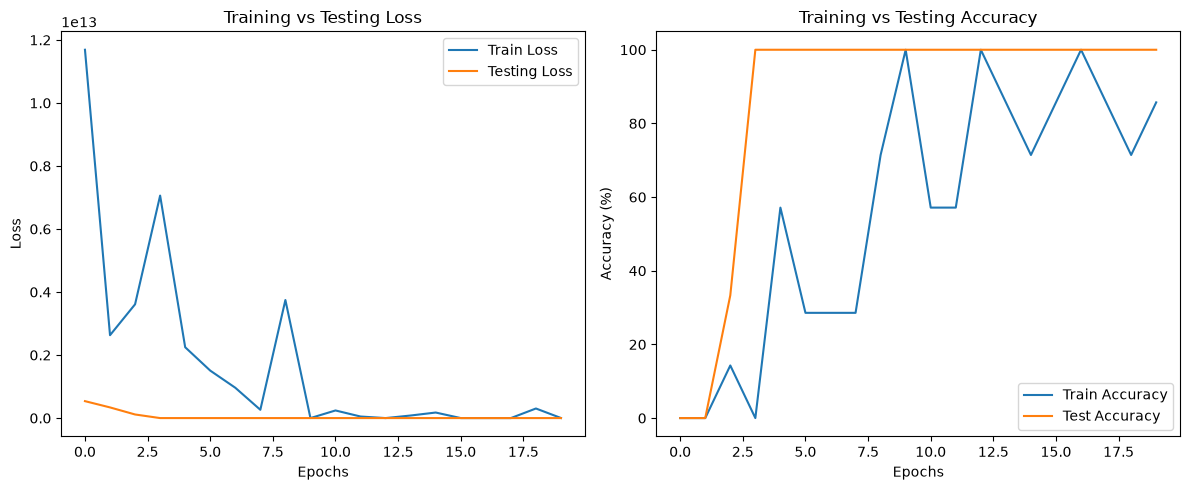

In [25]:
# Test the model and calculate F1 score
accuracy, avg_test_loss, f1 = test_model(model, test_loader, device=device)

# Plot the training vs validation metrics
plot_training_vs_validation(train_losses, val_losses, train_accuracies, val_accuracies)
